**Parsing Data**

In [ ]:
import numpy as np
import pandas as pd

dataset = pd.read_csv('/content/reddit_comments_citizenship.csv')
dataset.head()

,URL,Author,Comment,Created_UTC
0,https://www.reddit.com/r/immigration/comments/...,Bwab,Good succinct coverage. Thank you. But I think...,1/22/2025 3:44
1,https://www.reddit.com/r/immigration/comments/...,Fabulous-Pianist1894,Not a lawyer.\n\n\n\nThe key phrase is “…and s...,1/22/2025 3:45
2,https://www.reddit.com/r/immigration/comments/...,Annoyinglygood,Everyone understands that this will be challen...,1/22/2025 3:48
3,https://www.reddit.com/r/immigration/comments/...,Shitcoinfinder,And lower food prices?? Eggs 🥚🥚 $2 each??\nSo ...,1/22/2025 4:05
4,https://www.reddit.com/r/immigration/comments/...,Navvyarchos,I'd add that even limited immunity doesn't cut...,1/22/2025 3:50


**Data Pre-Processing**

In [ ]:
pip install emoji


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import re
import emoji

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # Emoticons
                           u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # Transport & map symbols
                           u"\U0001F700-\U0001F77F"  # Alchemical symbols
                           u"\U0001F780-\U0001F7FF"  # Geometric shapes
                           u"\U0001F800-\U0001F8FF"  # Supplemental arrows
                           u"\U0001F900-\U0001F9FF"  # Supplemental symbols
                           u"\U0001FA00-\U0001FA6F"  # Chess pieces, symbols
                           u"\U0001FA70-\U0001FAFF"  # Other pictographs
                           u"\U00002702-\U000027B0"  # Dingbats
                           u"\U000024C2-\U0001F251"  # Enclosed characters
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def clean_text(x):
    x = str(x)
    x = x.lower()
    x = remove_emojis(x)  # Removing emojis
    x = re.sub(r'#[A-Za-z0-9]*', ' ', x)  # Removing hashtags
    x = re.sub(r'https*://.*', ' ', x)  # Removing URLs
    x = re.sub(r'@[A-Za-z0-9]+', ' ', x)  # Removing mentions (@user)
    tokens = word_tokenize(x)
    x = ' '.join([w for w in tokens if w.lower() not in stop_words])  # Removing stopwords
    x = re.sub(r'[%s]' % re.escape('!"#$%&\()*+,-./:;<=>?@[\\]^_`{|}~“…”’'), ' ', x)  # Removing punctuations
    x = re.sub(r'\d+', ' ', x)  # Removing numbers
    x = re.sub(r'\n+', ' ', x)  # Removing new lines
    x = re.sub(r'\s{2,}', ' ', x)  # Removing extra spaces
    return x.strip()

# Apply function to DataFrame
dataset['processed_text'] = dataset['Comment'].apply(clean_text)
dataset.head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,URL,Author,Comment,Created_UTC,processed_text
0,https://www.reddit.com/r/immigration/comments/...,Bwab,Good succinct coverage. Thank you. But I think...,1/22/2025 3:44,good succinct coverage thank think summary sev...
1,https://www.reddit.com/r/immigration/comments/...,Fabulous-Pianist1894,Not a lawyer.\n\n\n\nThe key phrase is “…and s...,1/22/2025 3:45,lawyer key phrase and subject jurisdiction the...
2,https://www.reddit.com/r/immigration/comments/...,Annoyinglygood,Everyone understands that this will be challen...,1/22/2025 3:48,everyone understands challenged court question...
3,https://www.reddit.com/r/immigration/comments/...,Shitcoinfinder,And lower food prices?? Eggs 🥚🥚 $2 each??\nSo ...,1/22/2025 4:05,lower food prices eggs much time spent worthle...
4,https://www.reddit.com/r/immigration/comments/...,Navvyarchos,I'd add that even limited immunity doesn't cut...,1/22/2025 3:50,'d add even limited immunity n't cut children ...


**Bert Model**


In [ ]:
! pip install bertopic

In [ ]:
from bertopic import BERTopic

**Topic Modeling Using BERT**

In [ ]:
topic_model = BERTopic(language="english")
topics, probs = topic_model.fit_transform(dataset['processed_text'])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2238,-1_citizenship_people_nt_trump,"[citizenship, people, nt, trump, court, would,...",[answer actual reason wants stop called anchor...
1,0,116,0_deleted___,"[deleted, , , , , , , , , ]","[deleted, deleted, deleted]"
2,1,83,1_jurisdiction_subject_diplomats_immunity,"[jurisdiction, subject, diplomats, immunity, u...",[diplomats diplomatic immunity reciprocal agre...
3,2,81,2_amendment_constitution_nd_amendments,"[amendment, constitution, nd, amendments, repe...",[amendment ca n't unconstitutional 's literall...
4,3,81,3_removed_sniper_top_remove,"[removed, sniper, top, remove, told, comment, ...","[removed, removed, removed]"
...,...,...,...,...,...
87,86,11,86_time_longtime_slightest_past,"[time, longtime, slightest, past, goalposts, c...","['s time got tired carrying, uh oh looks like ..."
88,87,10,87_austria_parents_germany_mistaken,"[austria, parents, germany, mistaken, blood, b...",['re right countries follow citizenship blood ...
89,88,10,88_principal_ius_precedent_executive,"[principal, ius, precedent, executive, order, ...",[eo hold still perform action supreme court ga...
90,89,10,89_scotus_constitution_mere_amendments,"[scotus, constitution, mere, amendments, offic...",[honestly doubt hear even poor decisions none ...


In [ ]:
topic_model.visualize_barchart(top_n_topics=12, n_words = 50, width = 350, height = 350)

In [ ]:
topic_model.visualize_hierarchy(top_n_topics=12, width = 700, height = 700)

In [ ]:
!pip install --upgrade --force-reinstall gensim

  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (83 kB)
  Att

In [ ]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

def calculate_coherence_score(data, min_k=2, max_k=10):
    coherence_scores = []

    for k in range(min_k, max_k + 1):
        # Train BERTopic model with K topics
        model = BERTopic(nr_topics=k)
        topics, _ = model.fit_transform(data)

        # Extract topic words
        topic_words = [ [word for word, _ in model.get_topic(topic)] for topic in model.get_topics().keys() if topic != -1 ]

        # Prepare data for Coherence Model
        tokenized_data = [doc.split() for doc in data]
        dictionary = Dictionary(tokenized_data)

        # Compute Coherence Score
        coherence_model = CoherenceModel(topics=topic_words, dictionary=dictionary, texts=tokenized_data, coherence='c_v')
        coherence_score = coherence_model.get_coherence()
        coherence_scores.append((k, coherence_score))

        print(f"K={k}, Coherence Score={coherence_score}")

    return coherence_scores


coherence_scores = calculate_coherence_score(dataset['processed_text'], min_k=2, max_k=20)


K=2, Coherence Score=0.5776715093243587
K=3, Coherence Score=0.4719849219397586
K=4, Coherence Score=0.4709501571320999
K=5, Coherence Score=0.4921717983436533
K=6, Coherence Score=0.40915599115260265
K=7, Coherence Score=0.5265578058145389
K=8, Coherence Score=0.39772038329293175
K=9, Coherence Score=0.4776044761142149
K=10, Coherence Score=0.44300782378581655
K=11, Coherence Score=0.5206147065276617
K=12, Coherence Score=0.4862615891445271
K=13, Coherence Score=0.5434434724179665
K=14, Coherence Score=0.47537160389229965
K=15, Coherence Score=0.4529470703965181
K=16, Coherence Score=0.49282935858034604
K=17, Coherence Score=0.46602650264830103
K=18, Coherence Score=0.4070458865639184
K=19, Coherence Score=0.46099248385351443
K=20, Coherence Score=0.4728628092775134


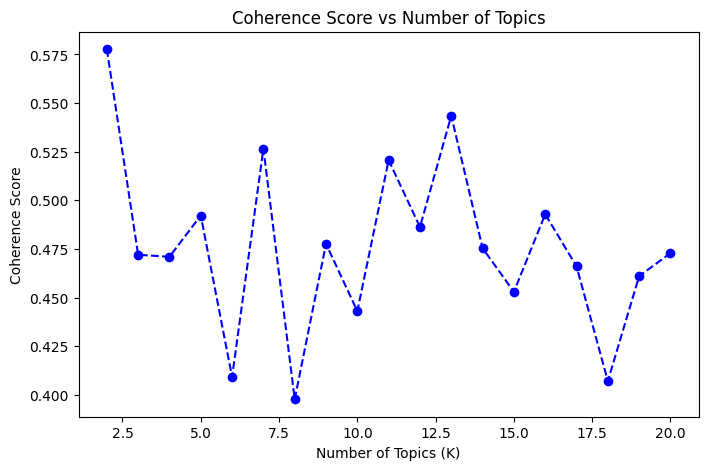

In [ ]:
import matplotlib.pyplot as plt

k_values, scores = zip(*coherence_scores)

plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker='o', linestyle='dashed', color='b')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Coherence Score vs Number of Topics")
plt.show()


**ROberta model**

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch
from tqdm import tqdm



# Load RoBERTa model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Define a function to predict sentiment
def get_sentiment(text):
    try:
        # Tokenize text
        encoded_input = tokenizer(text, return_tensors='pt', truncation=True)
        with torch.no_grad():
            output = model(**encoded_input)
        scores = softmax(output.logits.numpy()[0])
        sentiment = ['negative', 'neutral', 'positive'][scores.argmax()]
        return sentiment
    except:
        return "error"

# Apply sentiment analysis
tqdm.pandas()  # Progress bar
dataset['sentiment'] = dataset['processed_text'].progress_apply(get_sentiment)

# Save the results
dataset.to_csv("reddit_comments_with_sentiment.csv", index=False)
print("Sentiment analysis completed and saved to 'reddit_comments_with_sentiment.csv'.")


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

  0%|          | 16/4892 [00:04<44:04,  1.84it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

100%|██████████| 4892/4892 [12:56<00:00,  6.30it/s]

Sentiment analysis completed and saved to 'reddit_comments_with_sentiment.csv'.


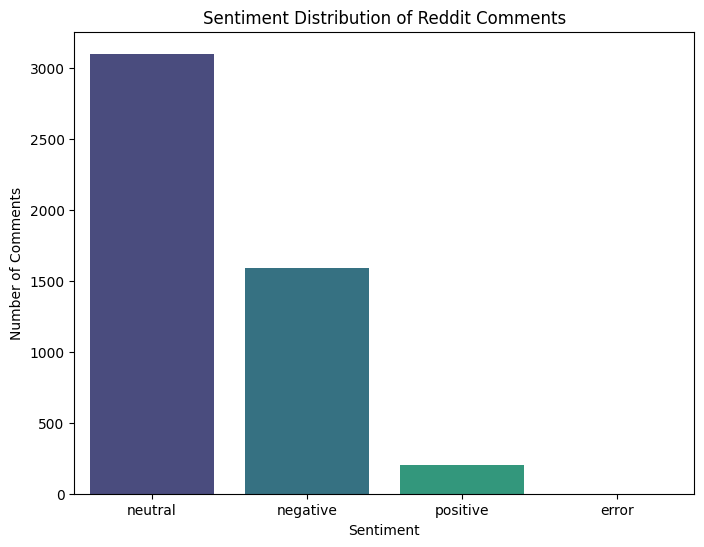

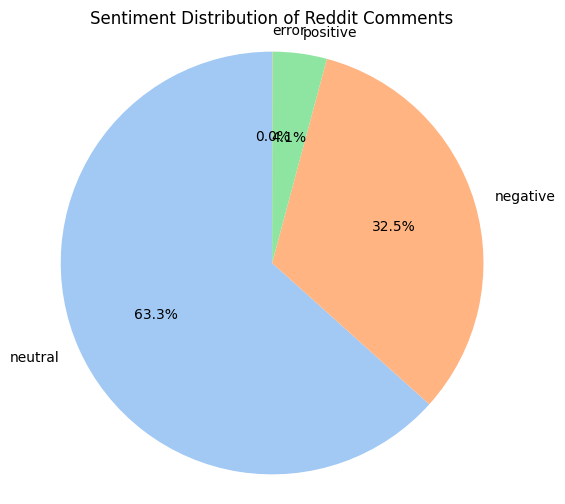

In [ ]:
# prompt: generate a visualization for above sentiment

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with sentiment analysis results
dataset = pd.read_csv("reddit_comments_with_sentiment.csv")

# Count the occurrences of each sentiment
sentiment_counts = dataset['sentiment'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.title("Sentiment Distribution of Reddit Comments")
plt.show()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Sentiment Distribution of Reddit Comments")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [ ]:
import numpy as np

def classify_emotion(sentiment):
    """Classifies emotion based on sentiment string.

    Args:
        sentiment (str): The sentiment string ("positive", "negative", "neutral").

    Returns:
        str: The emotion category ("Positive", "Negative", "Neutral").
    """

    if sentiment == "positive":
        return "Positive"
    elif sentiment == "negative":
        return "Negative"
    else:  # sentiment == "neutral"
        # For neutral cases, use a small random value to nudge towards positive or negative
        if np.random.rand() > 0.5:
            return "Positive"  # Nudge towards positive
        else:
            return "Negative"  # Nudge towards negative


# Apply the emotion classification function to the 'sentiment' column
dataset['emotion'] = dataset['sentiment'].apply(classify_emotion)

# Print the results (or further process them as needed)
print(dataset[['processed_text', 'sentiment', 'emotion']].head())

                                      processed_text sentiment   emotion
0  good succinct coverage thank think summary sev...  positive  Positive
1  lawyer key phrase and subject jurisdiction the...   neutral  Positive
2  everyone understands challenged court question...   neutral  Positive
3  lower food prices eggs much time spent worthle...  negative  Negative
4  'd add even limited immunity n't cut children ...   neutral  Negative


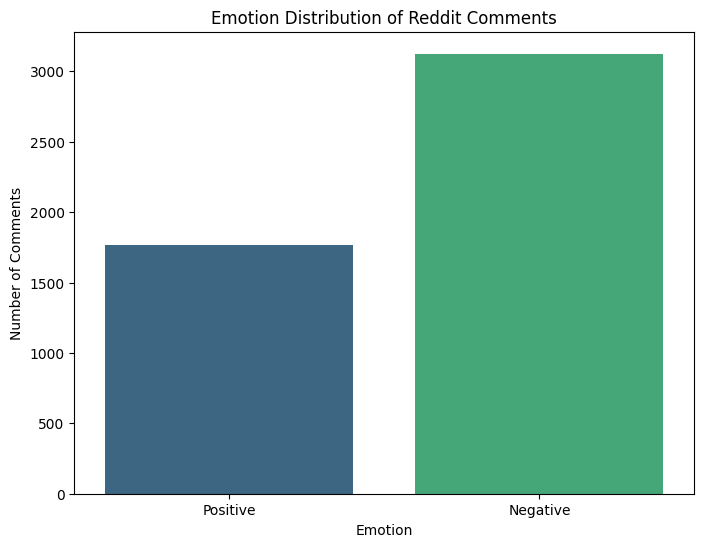

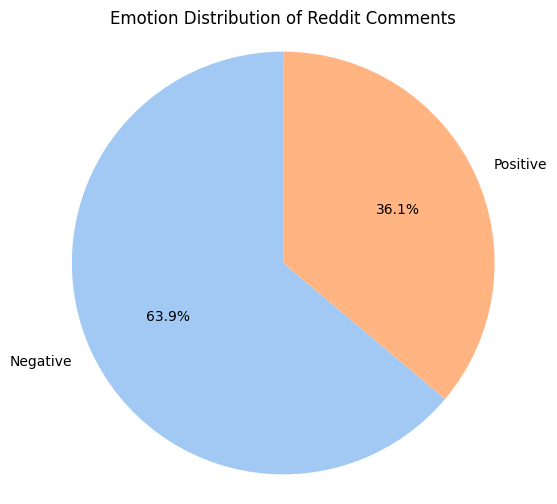

In [ ]:
# prompt: now visualize this above code

import matplotlib.pyplot as plt
import seaborn as sns
# Create a bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x='emotion', data=dataset, palette="viridis")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")
plt.title("Emotion Distribution of Reddit Comments")
plt.show()


# Create a pie chart
emotion_counts = dataset['emotion'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Emotion Distribution of Reddit Comments")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


**ABSA(Aspect Based Sentiment Analysis)**

In [ ]:
!pip install -U pyabsa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.5/575.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 13.0 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=1696566f713e9f5cb94168a3e10118a9de4299bb8c1d68e3666fc79ef4ceec2c
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
from tqdm import tqdm


In [ ]:

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load sentiment model
print("📦 Loading sentiment model for ABSA...")
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

# Define fixed aspects to analyze
aspects = ["immigration", "ICE", "LGBTQ", "tariffs"]

# Function to classify sentiment for each aspect
def absa_infer(row_text):
    results = []
    for aspect in aspects:
        prompt = f"Sentiment about {aspect}: {row_text}"
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = softmax(logits, dim=-1).cpu().numpy()[0]
            label = "positive" if probs[1] > 0.6 else "negative" if probs[0] > 0.6 else "neutral"
        results.append((aspect, label))
    return results

📦 Loading sentiment model for ABSA...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from scipy.special import softmax
from tqdm import tqdm

# Load your dataset
df = pd.read_csv("/content/reddit_comments_with_sentiment.csv")

# Load ABSA model and tokenizer
model_name = "yangheng/deberta-v3-base-absa-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Define aspects you want to analyze
aspects = ["government", "citizenship", "immigration", "rights"]

# Function to analyze sentiment for each aspect
def absa_sentiment(text, aspect):
    try:
        aspect_text = f"{aspect} [SEP] {text}"  # This format is expected by the ABSA model
        inputs = tokenizer(aspect_text, return_tensors="pt", truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
        scores = softmax(outputs.logits.numpy()[0])
        label = ['negative', 'neutral', 'positive'][scores.argmax()]
        return label
    except:
        return "error"

# Apply ABSA for each aspect
for aspect in aspects:
    tqdm.pandas(desc=f"Processing aspect: {aspect}")
    df[f"sentiment_{aspect}"] = df['processed_text'].progress_apply(lambda x: absa_sentiment(x, aspect))

# Save the result
df.to_csv("reddit_comments_absa.csv", index=False)
print("ABSA Sentiment analysis complete! Results saved to 'reddit_comments_absa.csv'.")


tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Processing aspect: rights: 100%|██████████| 4892/4892 [41:40<00:00,  1.96it/s]

ABSA Sentiment analysis complete! Results saved to 'reddit_comments_absa.csv'.


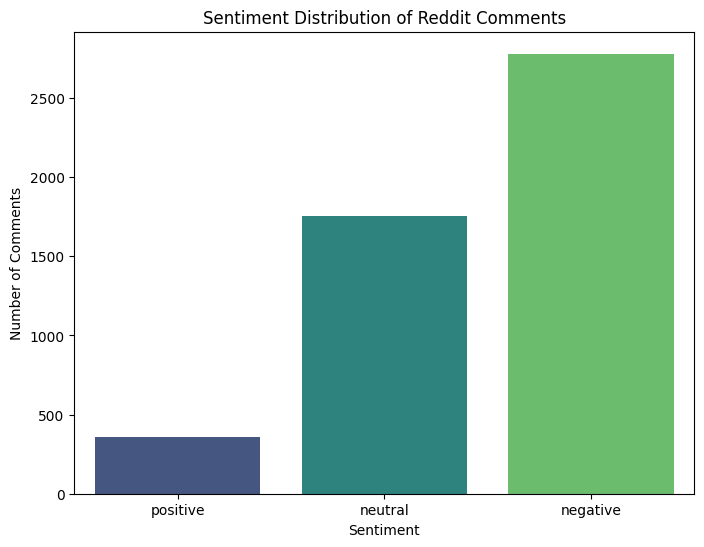

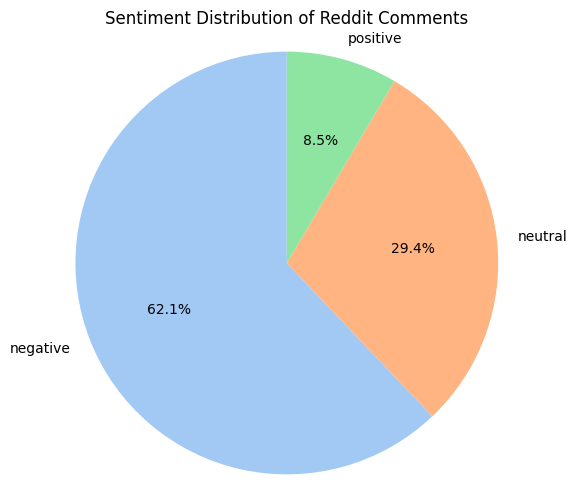

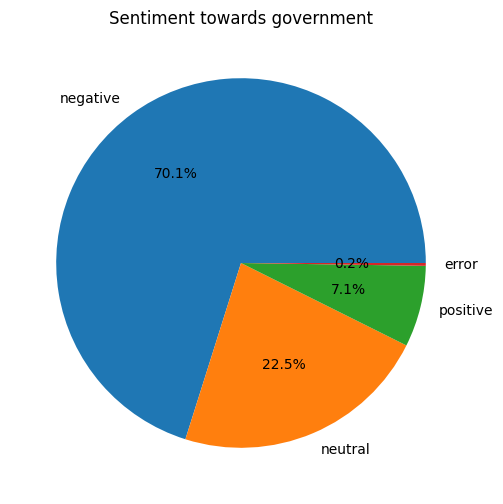

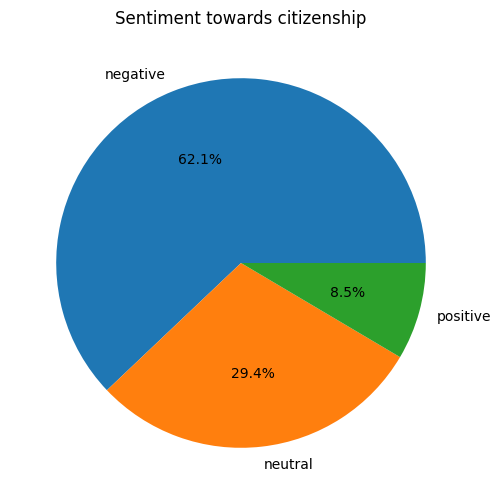

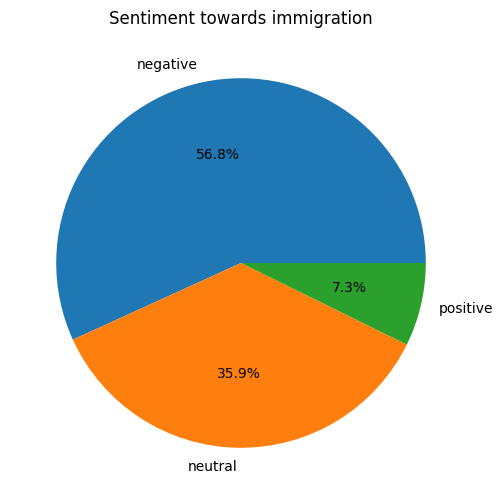

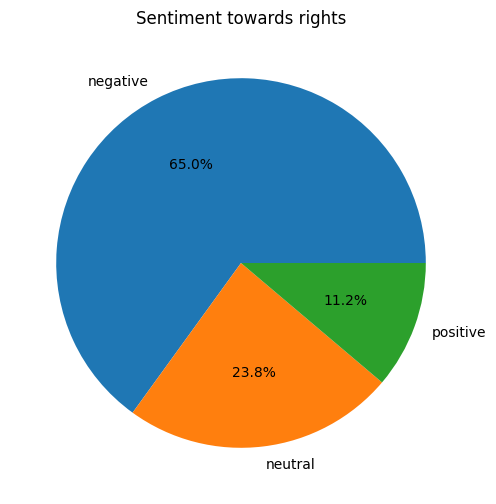

In [ ]:
# prompt: visualize the above code

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'dataset' DataFrame is already loaded and processed as in the original code

# Bar plot for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_immigration', data=df, palette="viridis")  # Use 'sentiment' column
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.title("Sentiment Distribution of Reddit Comments")
plt.show()


# Pie chart for sentiment distribution
sentiment_counts = df['sentiment_citizenship'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Sentiment Distribution of Reddit Comments")
plt.axis('equal')
plt.show()






# Example visualization for aspect-based sentiment analysis (ABSA)
# Replace with your actual aspect data
# Example:
aspects = ["government", "citizenship", "immigration", "rights"]
for aspect in aspects:
    aspect_sentiment_counts = df[f"sentiment_{aspect}"].value_counts()
    plt.figure(figsize=(6, 6))
    plt.pie(aspect_sentiment_counts, labels=aspect_sentiment_counts.index, autopct='%1.1f%%')
    plt.title(f"Sentiment towards {aspect}")
    plt.show()
